In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset

REPO_ID = "witgaw/METR-LA"

ZERO_THRESHOLD = 1.0

# Drift detector parameters
CUSUM_THRESHOLD = 5.0
CUSUM_DRIFT = 0.5

EWMA_ALPHA = 0.2
EWMA_LIMIT = 3.0

print("Notebook 02 — Sensor Reliability & Drift Analysis")
print("Dataset:", REPO_ID)

Notebook 02 — Sensor Reliability & Drift Analysis
Dataset: witgaw/METR-LA


In [2]:
train = load_dataset(
    REPO_ID,
    split="train"
)

print(train)

print("\nRows    :", train.num_rows)
print("Columns :", len(train.column_names))

assert train.num_rows > 0
assert "node_id" in train.column_names
assert "t0_timestamp" in train.column_names

sensor_ids = train.unique("node_id")

print("Sensors :", len(sensor_ids))

assert len(sensor_ids) == 207

print("\nPASS: METR-LA loaded.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


Dataset({
    features: ['node_id', 't0_timestamp', 'x_t-11_d0', 'x_t-11_d1', 'x_t-10_d0', 'x_t-10_d1', 'x_t-9_d0', 'x_t-9_d1', 'x_t-8_d0', 'x_t-8_d1', 'x_t-7_d0', 'x_t-7_d1', 'x_t-6_d0', 'x_t-6_d1', 'x_t-5_d0', 'x_t-5_d1', 'x_t-4_d0', 'x_t-4_d1', 'x_t-3_d0', 'x_t-3_d1', 'x_t-2_d0', 'x_t-2_d1', 'x_t-1_d0', 'x_t-1_d1', 'x_t+0_d0', 'x_t+0_d1', 'y_t+1_d0', 'y_t+1_d1', 'y_t+2_d0', 'y_t+2_d1', 'y_t+3_d0', 'y_t+3_d1', 'y_t+4_d0', 'y_t+4_d1', 'y_t+5_d0', 'y_t+5_d1', 'y_t+6_d0', 'y_t+6_d1', 'y_t+7_d0', 'y_t+7_d1', 'y_t+8_d0', 'y_t+8_d1', 'y_t+9_d0', 'y_t+9_d1', 'y_t+10_d0', 'y_t+10_d1', 'y_t+11_d0', 'y_t+11_d1', 'y_t+12_d0', 'y_t+12_d1'],
    num_rows: 4962618
})

Rows    : 4962618
Columns : 50
Sensors : 207

PASS: METR-LA loaded.


In [3]:
if "x_t+0_d0" in train.column_names:
    CURRENT_SPEED = "x_t+0_d0"

elif "x_t-0_d0" in train.column_names:
    CURRENT_SPEED = "x_t-0_d0"

else:
    raise AssertionError(
        "Could not identify the current-time d0 speed column."
    )


print("Current speed column:", CURRENT_SPEED)

assert CURRENT_SPEED in train.column_names

print("\nPASS: Current speed column identified.")

Current speed column: x_t+0_d0

PASS: Current speed column identified.


In [4]:
traffic = (
    train
    .select_columns([
        "node_id",
        "t0_timestamp",
        CURRENT_SPEED
    ])
    .to_pandas()
)

traffic = traffic.rename(
    columns={
        CURRENT_SPEED: "speed"
    }
)

traffic["node_id"] = (
    traffic["node_id"]
    .astype(int)
)

traffic["t0_timestamp"] = pd.to_datetime(
    traffic["t0_timestamp"]
)

traffic = (
    traffic
    .sort_values([
        "node_id",
        "t0_timestamp"
    ])
    .reset_index(drop=True)
)


print("Rows       :", len(traffic))
print("Sensors    :", traffic["node_id"].nunique())
print("Timestamps :", traffic["t0_timestamp"].nunique())

assert traffic["node_id"].nunique() == 207

assert not traffic.duplicated(
    ["node_id", "t0_timestamp"]
).any()

assert traffic["speed"].notna().all()

print("\nPASS: Continuous sensor series reconstructed.")

Rows       : 4962618
Sensors    : 207
Timestamps : 23974

PASS: Continuous sensor series reconstructed.


In [5]:
traffic["near_zero"] = (
    traffic["speed"] <= ZERO_THRESHOLD
)

overall_zero_rate = (
    traffic["near_zero"].mean()
)

failure_df = (
    traffic
    .groupby("node_id", as_index=False)
    .agg(
        zero_rate=(
            "near_zero",
            "mean"
        ),
        observations=(
            "speed",
            "size"
        )
    )
)


print("=" * 65)
print("NEAR-ZERO SENSOR FAILURE ANALYSIS")
print("=" * 65)

print(
    f"Near-zero threshold    : <= {ZERO_THRESHOLD:.1f} mph"
)

print(
    f"Overall near-zero rate : {overall_zero_rate:.4%}"
)

print("\nPer-sensor zero-rate distribution:")

print(
    failure_df["zero_rate"]
    .describe()
)


assert len(failure_df) == 207

assert (
    failure_df["zero_rate"]
    .between(0, 1)
    .all()
)

print("\nPASS: Near-zero failure metric computed.")

NEAR-ZERO SENSOR FAILURE ANALYSIS
Near-zero threshold    : <= 1.0 mph
Overall near-zero rate : 7.1285%

Per-sensor zero-rate distribution:
count    207.000000
mean       0.071285
std        0.025733
min        0.054184
25%        0.054955
50%        0.057771
75%        0.080045
max        0.229582
Name: zero_rate, dtype: float64

PASS: Near-zero failure metric computed.


In [6]:
METR_LA_REFERENCE = 0.08
PEMS_BAY_REFERENCE = 0.00003

difference = abs(
    overall_zero_rate
    - METR_LA_REFERENCE
)


print("=" * 65)
print("ZERO-RATE SANITY CHECK")
print("=" * 65)

print(
    f"Observed METR-LA rate : {overall_zero_rate:.4%}"
)

print(
    f"Sanity reference      : ~{METR_LA_REFERENCE:.1%}"
)

print(
    f"PEMS-BAY comparison   : ~{PEMS_BAY_REFERENCE:.3%}"
)

print(
    "\nNOTE: The reference values here are supplied "
    "sanity-check values."
)

print(
    "They should be traced to a primary source before "
    "being cited in the dissertation."
)


if difference <= 0.03:

    print(
        "\nPASS: Observed zero-rate is in a similar "
        "ballpark to the METR-LA sanity reference."
    )

else:

    print(
        "\nWARNING: Observed zero-rate is substantially "
        "different from the expected METR-LA ballpark."
    )

    print(
        "The parquet may have been cleaned or altered."
    )


assert 0 <= overall_zero_rate <= 1

ZERO-RATE SANITY CHECK
Observed METR-LA rate : 7.1285%
Sanity reference      : ~8.0%
PEMS-BAY comparison   : ~0.003%

NOTE: The reference values here are supplied sanity-check values.
They should be traced to a primary source before being cited in the dissertation.

PASS: Observed zero-rate is in a similar ballpark to the METR-LA sanity reference.


In [7]:
traffic["day_of_week"] = (
    traffic["t0_timestamp"].dt.dayofweek
)

traffic["hour"] = (
    traffic["t0_timestamp"].dt.hour
)

traffic["minute"] = (
    traffic["t0_timestamp"].dt.minute
)

traffic["time_slot"] = (
    traffic["hour"] * 12
    + traffic["minute"] // 5
)


print(
    traffic[
        [
            "t0_timestamp",
            "day_of_week",
            "hour",
            "minute",
            "time_slot"
        ]
    ]
    .head(10)
    .to_string(index=False)
)


assert traffic["day_of_week"].between(0, 6).all()
assert traffic["time_slot"].between(0, 287).all()

print("\nPASS: Seasonal time keys created.")

       t0_timestamp  day_of_week  hour  minute  time_slot
2012-03-01 00:55:00            3     0      55         11
2012-03-01 01:00:00            3     1       0         12
2012-03-01 01:05:00            3     1       5         13
2012-03-01 01:10:00            3     1      10         14
2012-03-01 01:15:00            3     1      15         15
2012-03-01 01:20:00            3     1      20         16
2012-03-01 01:25:00            3     1      25         17
2012-03-01 01:30:00            3     1      30         18
2012-03-01 01:35:00            3     1      35         19
2012-03-01 01:40:00            3     1      40         20

PASS: Seasonal time keys created.


In [8]:
# ------------------------------------------------------------
# Split data into reference and monitoring periods
# ------------------------------------------------------------

start_date = traffic["t0_timestamp"].min()
end_date = traffic["t0_timestamp"].max()

print("Full dataset period:")
print("Start :", start_date)
print("End   :", end_date)


# Use the first calendar month as the fixed reference period
reference_end = (
    start_date.to_period("M") + 1
).start_time


reference_data = traffic[
    traffic["t0_timestamp"] < reference_end
].copy()

monitoring_data = traffic[
    traffic["t0_timestamp"] >= reference_end
].copy()


print("\nREFERENCE PERIOD")
print(
    reference_data["t0_timestamp"].min(),
    "to",
    reference_data["t0_timestamp"].max()
)

print("Rows:", len(reference_data))


print("\nMONITORING PERIOD")
print(
    monitoring_data["t0_timestamp"].min(),
    "to",
    monitoring_data["t0_timestamp"].max()
)

print("Rows:", len(monitoring_data))


# ------------------------------------------------------------
# Remove near-zero sensor failures ONLY when learning
# the normal seasonal baseline
# ------------------------------------------------------------

normal_reference = reference_data[
    reference_data["speed"] > ZERO_THRESHOLD
].copy()


# ------------------------------------------------------------
# Build baseline ONLY from reference-period observations
# ------------------------------------------------------------

seasonal_baseline = (
    normal_reference
    .groupby(
        [
            "node_id",
            "day_of_week",
            "time_slot"
        ],
        as_index=False
    )
    .agg(
        expected_speed=(
            "speed",
            "mean"
        ),
        baseline_samples=(
            "speed",
            "size"
        )
    )
)


print(
    "\nSeasonal baseline rows:",
    len(seasonal_baseline)
)

print(
    "\nBaseline sample-count distribution:"
)

print(
    seasonal_baseline[
        "baseline_samples"
    ].describe()
)


# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

assert len(reference_data) > 0, (
    "Reference period is empty."
)

assert len(monitoring_data) > 0, (
    "Monitoring period is empty."
)

assert (
    reference_data["t0_timestamp"].max()
    <
    monitoring_data["t0_timestamp"].min()
), "Reference and monitoring periods overlap."


assert len(seasonal_baseline) > 0

assert (
    seasonal_baseline["expected_speed"]
    > ZERO_THRESHOLD
).all()


print(
    "\nPASS: Fixed reference-period seasonal baseline constructed."
)

Full dataset period:
Start : 2012-03-01 00:55:00
End   : 2012-05-23 06:40:00

REFERENCE PERIOD
2012-03-01 00:55:00 to 2012-03-31 23:55:00
Rows: 1845819

MONITORING PERIOD
2012-04-01 00:00:00 to 2012-05-23 06:40:00
Rows: 3116799

Seasonal baseline rows: 417174

Baseline sample-count distribution:
count    417174.000000
mean          4.025220
std           0.821916
min           1.000000
25%           4.000000
50%           4.000000
75%           5.000000
max           5.000000
Name: baseline_samples, dtype: float64

PASS: Fixed reference-period seasonal baseline constructed.


In [9]:
monitoring_data = monitoring_data.merge(
    seasonal_baseline,
    on=[
        "node_id",
        "day_of_week",
        "time_slot"
    ],
    how="left"
)


# ------------------------------------------------------------
# Check baseline coverage
# ------------------------------------------------------------

baseline_match_rate = (
    monitoring_data["expected_speed"]
    .notna()
    .mean()
)


missing_baseline = (
    monitoring_data["expected_speed"]
    .isna()
    .sum()
)


print("=" * 65)
print("OUT-OF-SAMPLE BASELINE COVERAGE")
print("=" * 65)

print(
    f"Monitoring rows        : {len(monitoring_data):,}"
)

print(
    f"Baseline matched rows  : "
    f"{monitoring_data['expected_speed'].notna().sum():,}"
)

print(
    f"Missing baseline rows  : {missing_baseline:,}"
)

print(
    f"Baseline match rate    : {baseline_match_rate:.4%}"
)


# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

assert len(monitoring_data) > 0

assert baseline_match_rate > 0.95, (
    f"Baseline coverage too low: {baseline_match_rate:.4%}"
)


print(
    "\nPASS: March seasonal baseline successfully "
    "applied to the April-May monitoring period."
)

OUT-OF-SAMPLE BASELINE COVERAGE
Monitoring rows        : 3,116,799
Baseline matched rows  : 3,115,761
Missing baseline rows  : 1,038
Baseline match rate    : 99.9667%

PASS: March seasonal baseline successfully applied to the April-May monitoring period.


In [10]:
# ------------------------------------------------------------
# Compute OUT-OF-SAMPLE residuals
# April-May observations are compared against the fixed
# March seasonal baseline
# ------------------------------------------------------------

monitoring_data["residual"] = (
    monitoring_data["speed"]
    - monitoring_data["expected_speed"]
)


# ------------------------------------------------------------
# Drift analysis data
#
# Exclude:
# 1. Near-zero readings because these are already represented
#    by the zero-rate failure metric.
# 2. Rows without a March seasonal baseline.
# ------------------------------------------------------------

drift_data = monitoring_data[
    (
        monitoring_data["speed"] > ZERO_THRESHOLD
    )
    &
    (
        monitoring_data["expected_speed"].notna()
    )
].copy()


excluded_zero = (
    monitoring_data["speed"] <= ZERO_THRESHOLD
).sum()

excluded_missing_baseline = (
    monitoring_data["expected_speed"].isna()
).sum()


print("=" * 65)
print("OUT-OF-SAMPLE DE-SEASONALIZED RESIDUALS")
print("=" * 65)

print(
    f"Monitoring rows             : {len(monitoring_data):,}"
)

print(
    f"Near-zero rows excluded     : {excluded_zero:,}"
)

print(
    f"Missing-baseline rows       : {excluded_missing_baseline:,}"
)

print(
    f"Rows used for drift analysis: {len(drift_data):,}"
)


print("\nResidual distribution:")

print(
    drift_data["residual"].describe()
)


print(
    f"\nMean residual   : "
    f"{drift_data['residual'].mean():.4f} mph"
)

print(
    f"Median residual : "
    f"{drift_data['residual'].median():.4f} mph"
)


# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

assert len(drift_data) > 0

assert drift_data["residual"].notna().all()

assert (
    drift_data["speed"] > ZERO_THRESHOLD
).all()

assert (
    drift_data["t0_timestamp"]
    >= reference_end
).all()


print(
    "\nPASS: Out-of-sample residual series created "
    "using the fixed March baseline."
)

OUT-OF-SAMPLE DE-SEASONALIZED RESIDUALS
Monitoring rows             : 3,116,799
Near-zero rows excluded     : 187,158
Missing-baseline rows       : 1,038
Rows used for drift analysis: 2,929,172

Residual distribution:
count    2.929172e+06
mean     1.300922e-01
std      8.169411e+00
min     -6.794097e+01
25%     -1.475694e+00
50%      4.000000e-01
75%      2.253472e+00
max      6.325000e+01
Name: residual, dtype: float64

Mean residual   : 0.1301 mph
Median residual : 0.4000 mph

PASS: Out-of-sample residual series created using the fixed March baseline.


In [11]:
# ------------------------------------------------------------
# OUT-OF-SAMPLE SEASONALITY VALIDATION
#
# Compare:
#   raw April-May speed pattern
# vs
#   April-May residual pattern after subtracting March baseline
# ------------------------------------------------------------

raw_hourly = (
    monitoring_data[
        monitoring_data["speed"] > ZERO_THRESHOLD
    ]
    .groupby("hour")["speed"]
    .mean()
)

residual_hourly = (
    drift_data
    .groupby("hour")["residual"]
    .mean()
)


seasonality_check = pd.DataFrame({
    "raw_monitoring_speed": raw_hourly,
    "out_of_sample_residual": residual_hourly
})


print("=" * 65)
print("OUT-OF-SAMPLE SEASONALITY CHECK")
print("=" * 65)

print(
    seasonality_check
    .round(3)
    .to_string()
)


raw_hourly_range = (
    raw_hourly.max()
    - raw_hourly.min()
)

residual_hourly_range = (
    residual_hourly.max()
    - residual_hourly.min()
)


print(
    f"\nRaw monitoring hourly range : "
    f"{raw_hourly_range:.4f} mph"
)

print(
    f"Residual hourly range       : "
    f"{residual_hourly_range:.4f} mph"
)


reduction_pct = (
    1
    - residual_hourly_range / raw_hourly_range
) * 100


print(
    f"Hourly seasonality reduction: "
    f"{reduction_pct:.2f}%"
)


# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

assert raw_hourly_range > 0

assert residual_hourly_range >= 0


if residual_hourly_range < raw_hourly_range:

    print(
        "\nPASS: March baseline reduced the hourly "
        "seasonal structure in unseen April-May data."
    )

else:

    print(
        "\nWARNING: Seasonal adjustment did not reduce "
        "hourly structure in the monitoring period."
    )


assert residual_hourly_range < raw_hourly_range, (
    "Out-of-sample de-seasonalization failed to reduce "
    "the hourly traffic pattern."
)

OUT-OF-SAMPLE SEASONALITY CHECK
      raw_monitoring_speed  out_of_sample_residual
hour                                              
0                   62.845                  -0.048
1                   61.957                  -0.089
2                   61.059                   0.005
3                   59.757                  -0.082
4                   60.246                  -0.131
5                   61.914                  -0.024
6                   60.867                   0.877
7                   56.361                   0.746
8                   53.985                   0.407
9                   55.978                  -0.222
10                  57.773                  -0.780
11                  58.494                  -0.605
12                  58.298                  -0.470
13                  57.933                  -0.658
14                  57.067                  -0.003
15                  54.596                   0.077
16                  52.106                   0.191

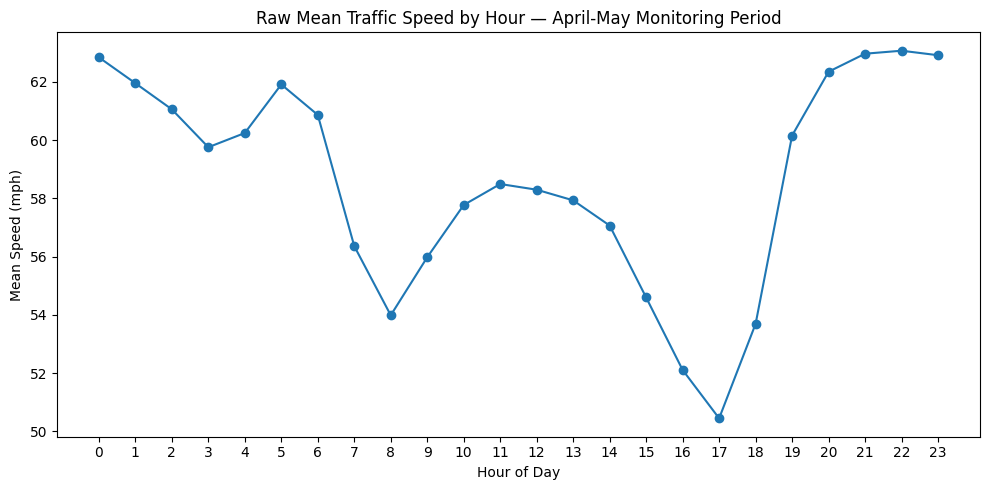

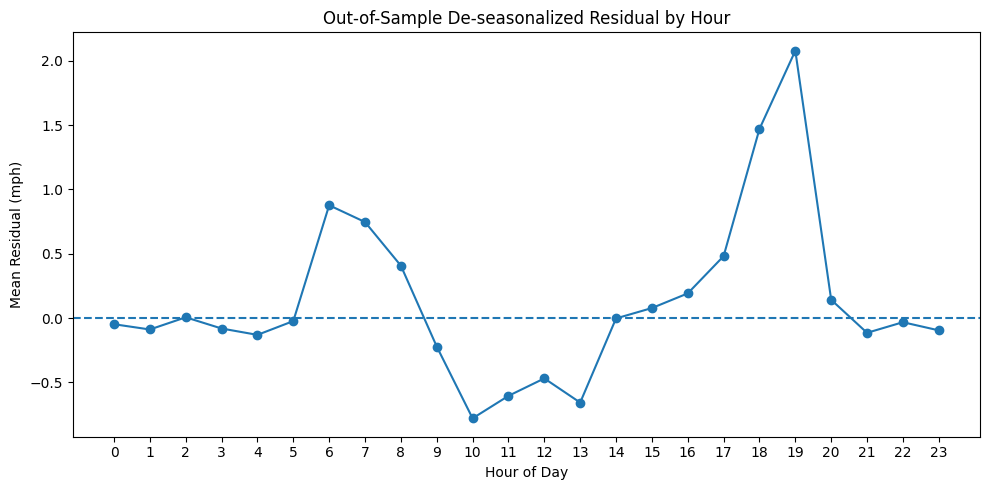

In [12]:
# ------------------------------------------------------------
# Plot raw monitoring-period hourly traffic pattern
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    raw_hourly.index,
    raw_hourly.values,
    marker="o"
)

ax.set_title(
    "Raw Mean Traffic Speed by Hour — April-May Monitoring Period"
)

ax.set_xlabel("Hour of Day")
ax.set_ylabel("Mean Speed (mph)")

ax.set_xticks(range(24))

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Plot out-of-sample residual hourly pattern
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    residual_hourly.index,
    residual_hourly.values,
    marker="o"
)

ax.axhline(
    0,
    linestyle="--"
)

ax.set_title(
    "Out-of-Sample De-seasonalized Residual by Hour"
)

ax.set_xlabel("Hour of Day")
ax.set_ylabel("Mean Residual (mph)")

ax.set_xticks(range(24))

plt.tight_layout()
plt.show()

In [13]:
# ------------------------------------------------------------
# Build March reference residuals for control-chart calibration
# ------------------------------------------------------------

# For each March observation, expected speed is estimated
# without using that observation itself where possible.

reference_normal = reference_data[
    reference_data["speed"] > ZERO_THRESHOLD
].copy()


# Mean and count for each seasonal group
reference_group_stats = (
    reference_normal
    .groupby(
        [
            "node_id",
            "day_of_week",
            "time_slot"
        ]
    )["speed"]
    .agg(["sum", "count"])
    .reset_index()
)


reference_normal = reference_normal.merge(
    reference_group_stats,
    on=[
        "node_id",
        "day_of_week",
        "time_slot"
    ],
    how="left"
)


# Leave-one-out expected speed
reference_normal["reference_expected"] = np.where(
    reference_normal["count"] > 1,

    (
        reference_normal["sum"]
        - reference_normal["speed"]
    )
    /
    (
        reference_normal["count"]
        - 1
    ),

    np.nan
)


reference_normal["reference_residual"] = (
    reference_normal["speed"]
    - reference_normal["reference_expected"]
)


reference_residuals = reference_normal[
    reference_normal["reference_residual"].notna()
].copy()


print("=" * 65)
print("REFERENCE-PERIOD CONTROL CALIBRATION")
print("=" * 65)

print(
    "Reference residual rows:",
    f"{len(reference_residuals):,}"
)

print(
    reference_residuals[
        "reference_residual"
    ].describe()
)


assert len(reference_residuals) > 0

assert (
    reference_residuals["reference_residual"]
    .notna()
    .all()
)

print(
    "\nPASS: March reference residuals created "
    "without self-inclusion."
)

REFERENCE-PERIOD CONTROL CALIBRATION
Reference residual rows: 1,678,018
count    1.678018e+06
mean     1.084011e-17
std      7.844662e+00
min     -6.848958e+01
25%     -1.648148e+00
50%      2.886905e-01
75%      2.170139e+00
max      6.328241e+01
Name: reference_residual, dtype: float64

PASS: March reference residuals created without self-inclusion.


In [14]:
reference_control = (
    reference_residuals
    .groupby("node_id")
    ["reference_residual"]
    .agg(
        reference_mean="mean",
        reference_std="std",
        reference_count="size"
    )
    .reset_index()
)


print("=" * 65)
print("PER-SENSOR REFERENCE CONTROL PARAMETERS")
print("=" * 65)

print(
    reference_control.head(10)
    .round(4)
    .to_string(index=False)
)


print("\nReference std distribution:")

print(
    reference_control[
        "reference_std"
    ].describe()
)


assert len(reference_control) == 207

assert reference_control["node_id"].is_unique

assert (
    reference_control["reference_std"] > 0
).all()

assert (
    reference_control["reference_count"] > 0
).all()


print(
    "\nPASS: March control parameters estimated "
    "for all 207 sensors."
)

PER-SENSOR REFERENCE CONTROL PARAMETERS
 node_id  reference_mean  reference_std  reference_count
       0             0.0         9.7625             8151
       1            -0.0         3.5843             8256
       2             0.0         5.2568             8256
       3            -0.0         7.5984             8251
       4            -0.0         8.1918             8241
       5             0.0         9.3463             8251
       6             0.0         5.2387             8251
       7             0.0         2.9724             7995
       8             0.0         6.3697             8124
       9             0.0         9.5575             8118

Reference std distribution:
count    207.000000
mean       7.280444
std        2.949533
min        2.031268
25%        5.139617
50%        7.003821
75%        9.152366
max       18.021679
Name: reference_std, dtype: float64

PASS: March control parameters estimated for all 207 sensors.


In [15]:
def detect_cusum(
    values,
    reference_mean,
    reference_std,
    threshold=CUSUM_THRESHOLD,
    drift=CUSUM_DRIFT
):

    values = np.asarray(
        values,
        dtype=float
    )

    values = values[
        np.isfinite(values)
    ]

    if len(values) == 0:
        return 0

    if (
        not np.isfinite(reference_std)
        or reference_std <= 0
    ):
        return 0


    # Standardize April-May residuals using
    # FIXED March reference parameters
    z = (
        values - reference_mean
    ) / reference_std


    positive = 0.0
    negative = 0.0
    flags = 0


    for value in z:

        positive = max(
            0.0,
            positive + value - drift
        )

        negative = min(
            0.0,
            negative + value + drift
        )


        if (
            positive > threshold
            or negative < -threshold
        ):

            flags += 1

            positive = 0.0
            negative = 0.0


    return flags


print(
    "CUSUM detector defined using fixed "
    "March reference parameters."
)

CUSUM detector defined using fixed March reference parameters.


In [16]:
def detect_ewma(
    values,
    reference_mean,
    reference_std,
    alpha=EWMA_ALPHA,
    control_limit=EWMA_LIMIT
):

    values = np.asarray(
        values,
        dtype=float
    )

    values = values[
        np.isfinite(values)
    ]

    if len(values) == 0:
        return 0

    if (
        not np.isfinite(reference_std)
        or reference_std <= 0
    ):
        return 0


    # EWMA starts from the March reference mean
    ewma = reference_mean


    ewma_std = (
        reference_std
        * np.sqrt(
            alpha / (2 - alpha)
        )
    )


    upper = (
        reference_mean
        + control_limit * ewma_std
    )

    lower = (
        reference_mean
        - control_limit * ewma_std
    )


    flags = 0


    for value in values:

        ewma = (
            alpha * value
            + (1 - alpha) * ewma
        )


        if (
            ewma > upper
            or ewma < lower
        ):

            flags += 1


    return flags


print(
    "EWMA detector defined using fixed "
    "March reference parameters."
)

EWMA detector defined using fixed March reference parameters.


In [17]:
# ------------------------------------------------------------
# OUT-OF-SAMPLE DRIFT DETECTION
#
# Monitoring residuals : April-May
# Control parameters   : March reference period
# ------------------------------------------------------------

drift_results = []


# Make reference parameters easy to retrieve by node_id
reference_lookup = (
    reference_control
    .set_index("node_id")
)


for node_id, group in drift_data.groupby(
    "node_id",
    sort=True
):

    node_id = int(node_id)

    group = group.sort_values(
        "t0_timestamp"
    )


    residuals = (
        group["residual"]
        .to_numpy(dtype=float)
    )


    # --------------------------------------------------------
    # Validate monitoring residuals
    # --------------------------------------------------------

    assert len(residuals) > 0, (
        f"No monitoring residuals for sensor {node_id}."
    )

    assert np.isfinite(residuals).all(), (
        f"Non-finite monitoring residuals for sensor {node_id}."
    )


    # --------------------------------------------------------
    # Retrieve FIXED March reference parameters
    # --------------------------------------------------------

    assert node_id in reference_lookup.index, (
        f"Missing March reference parameters for sensor {node_id}."
    )


    reference_mean = float(
        reference_lookup.loc[
            node_id,
            "reference_mean"
        ]
    )

    reference_std = float(
        reference_lookup.loc[
            node_id,
            "reference_std"
        ]
    )

    reference_count = int(
        reference_lookup.loc[
            node_id,
            "reference_count"
        ]
    )


    assert np.isfinite(reference_mean), (
        f"Invalid reference mean for sensor {node_id}."
    )

    assert (
        np.isfinite(reference_std)
        and reference_std > 0
    ), (
        f"Invalid reference std for sensor {node_id}: "
        f"{reference_std}"
    )


    # --------------------------------------------------------
    # CUSUM using FIXED March calibration
    # --------------------------------------------------------

    cusum_flags = detect_cusum(
        residuals,
        reference_mean=reference_mean,
        reference_std=reference_std
    )


    # --------------------------------------------------------
    # EWMA using FIXED March calibration
    # --------------------------------------------------------

    ewma_flags = detect_ewma(
        residuals,
        reference_mean=reference_mean,
        reference_std=reference_std
    )


    drift_results.append({

        "node_id":
            node_id,

        "reference_mean":
            reference_mean,

        "reference_std":
            reference_std,

        "reference_count":
            reference_count,

        "cusum_flags":
            int(cusum_flags),

        "ewma_flags":
            int(ewma_flags),

        "drift_observations":
            len(residuals)
    })


# ------------------------------------------------------------
# Create final drift dataframe
# ------------------------------------------------------------

drift_df = pd.DataFrame(
    drift_results
)


print("=" * 70)
print("OUT-OF-SAMPLE DRIFT DETECTION")
print("=" * 70)


print(
    "Reference period  :",
    reference_data["t0_timestamp"].min(),
    "to",
    reference_data["t0_timestamp"].max()
)

print(
    "Monitoring period :",
    drift_data["t0_timestamp"].min(),
    "to",
    drift_data["t0_timestamp"].max()
)


print(
    "\nSensors analyzed :",
    len(drift_df)
)

print(
    "CUSUM flags total:",
    f"{drift_df['cusum_flags'].sum():,}"
)

print(
    "EWMA flags total :",
    f"{drift_df['ewma_flags'].sum():,}"
)


print("\nFirst 10 sensors:")

print(
    drift_df[
        [
            "node_id",
            "reference_mean",
            "reference_std",
            "reference_count",
            "cusum_flags",
            "ewma_flags",
            "drift_observations"
        ]
    ]
    .head(10)
    .round(4)
    .to_string(index=False)
)


# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

assert len(drift_df) == 207, (
    f"Expected 207 sensors, found {len(drift_df)}."
)

assert drift_df["node_id"].is_unique, (
    "Duplicate sensors found in drift results."
)


# Every monitoring sensor must have March calibration
assert set(drift_df["node_id"]) == set(
    reference_control["node_id"]
), (
    "Monitoring sensors and March reference sensors do not match."
)


assert (
    drift_df["reference_count"] > 0
).all()


assert (
    drift_df["reference_std"] > 0
).all()


assert (
    drift_df["cusum_flags"] >= 0
).all()


assert (
    drift_df["ewma_flags"] >= 0
).all()


assert (
    drift_df["drift_observations"] > 0
).all()


# ------------------------------------------------------------
# Critical leakage check
# ------------------------------------------------------------

assert (
    drift_data["t0_timestamp"] >= reference_end
).all(), (
    "Reference-period observations leaked into "
    "monitoring-period drift detection."
)


assert (
    reference_data["t0_timestamp"] < reference_end
).all(), (
    "Monitoring-period observations leaked into "
    "reference-period calibration."
)


print(
    "\nPASS: All 207 sensors analyzed."
)

print(
    "PASS: CUSUM used fixed March reference parameters."
)

print(
    "PASS: EWMA used fixed March reference parameters."
)

print(
    "PASS: No reference/monitoring temporal leakage detected."
)

print(
    "\nOUT-OF-SAMPLE DRIFT DETECTION COMPLETED SUCCESSFULLY."
)

OUT-OF-SAMPLE DRIFT DETECTION
Reference period  : 2012-03-01 00:55:00 to 2012-03-31 23:55:00
Monitoring period : 2012-04-01 00:00:00 to 2012-05-23 06:40:00

Sensors analyzed : 207
CUSUM flags total: 93,752
EWMA flags total : 312,454

First 10 sensors:
 node_id  reference_mean  reference_std  reference_count  cusum_flags  ewma_flags  drift_observations
       0             0.0         9.7625             8151          366        1292               13944
       1            -0.0         3.5843             8256          250         872               14417
       2             0.0         5.2568             8256          337         903               14417
       3            -0.0         7.5984             8251          542        1947               14409
       4            -0.0         8.1918             8241          566        2157               14374
       5             0.0         9.3463             8251         1026        4113               14410
       6             0.0         5

In [18]:
# ------------------------------------------------------------
# Convert monitoring-period flag counts to per-sensor rates
# ------------------------------------------------------------

drift_df["cusum_rate"] = (
    drift_df["cusum_flags"]
    / drift_df["drift_observations"]
)

drift_df["ewma_rate"] = (
    drift_df["ewma_flags"]
    / drift_df["drift_observations"]
)


print("=" * 65)
print("OUT-OF-SAMPLE DRIFT RATE SUMMARY")
print("=" * 65)

print("\nCUSUM rate:")

print(
    drift_df["cusum_rate"]
    .describe()
)


print("\nEWMA rate:")

print(
    drift_df["ewma_rate"]
    .describe()
)


print(
    f"\nMean CUSUM rate : "
    f"{drift_df['cusum_rate'].mean():.4%}"
)

print(
    f"Mean EWMA rate  : "
    f"{drift_df['ewma_rate'].mean():.4%}"
)


# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

assert (
    drift_df["cusum_rate"]
    .between(0, 1)
    .all()
)

assert (
    drift_df["ewma_rate"]
    .between(0, 1)
    .all()
)

assert np.isfinite(
    drift_df["cusum_rate"]
).all()

assert np.isfinite(
    drift_df["ewma_rate"]
).all()


print(
    "\nPASS: Out-of-sample CUSUM/EWMA rates computed."
)

OUT-OF-SAMPLE DRIFT RATE SUMMARY

CUSUM rate:
count    207.000000
mean       0.031912
std        0.013049
min        0.008827
25%        0.022213
50%        0.032197
75%        0.041333
max        0.071201
Name: cusum_rate, dtype: float64

EWMA rate:
count    207.000000
mean       0.106346
std        0.050423
min        0.024675
25%        0.064899
50%        0.099431
75%        0.150264
max        0.285427
Name: ewma_rate, dtype: float64

Mean CUSUM rate : 3.1912%
Mean EWMA rate  : 10.6346%

PASS: Out-of-sample CUSUM/EWMA rates computed.


In [19]:
# ------------------------------------------------------------
# FINAL SENSOR RELIABILITY TABLE
#
# zero_rate:
#   Full collection period, raw sensor-failure signal
#
# cusum_rate / ewma_rate:
#   April-May monitoring period using fixed March calibration
#
# Weights are heuristic, not learned model parameters.
# ------------------------------------------------------------

summary = (
    failure_df
    .merge(
        drift_df,
        on="node_id",
        how="inner",
        validate="one_to_one"
    )
)


# ------------------------------------------------------------
# Validate alignment
# ------------------------------------------------------------

assert len(summary) == 207, (
    f"Expected 207 sensors after merge, found {len(summary)}."
)

assert summary["node_id"].is_unique

assert set(summary["node_id"]) == set(
    failure_df["node_id"]
)

assert set(summary["node_id"]) == set(
    drift_df["node_id"]
)


# ------------------------------------------------------------
# Composite reliability score
# ------------------------------------------------------------

ZERO_WEIGHT = 0.50
CUSUM_WEIGHT = 0.25
EWMA_WEIGHT = 0.25


assert np.isclose(
    ZERO_WEIGHT + CUSUM_WEIGHT + EWMA_WEIGHT,
    1.0
)


summary["reliability_penalty"] = (
    ZERO_WEIGHT * summary["zero_rate"]
    +
    CUSUM_WEIGHT * summary["cusum_rate"]
    +
    EWMA_WEIGHT * summary["ewma_rate"]
)


summary["reliability_score"] = (
    1.0
    - summary["reliability_penalty"]
)


# Numerical safety only
summary["reliability_score"] = (
    summary["reliability_score"]
    .clip(0, 1)
)


# ------------------------------------------------------------
# Output
# ------------------------------------------------------------

print("=" * 70)
print("FINAL SENSOR RELIABILITY SCORE")
print("=" * 70)

print(
    "Failure signal period : Full available collection window"
)

print(
    "Drift reference       : March 2012"
)

print(
    "Drift monitoring      : April-May 2012"
)

print("\nHeuristic weights:")
print(f"  Near-zero failure : {ZERO_WEIGHT:.0%}")
print(f"  CUSUM drift       : {CUSUM_WEIGHT:.0%}")
print(f"  EWMA drift        : {EWMA_WEIGHT:.0%}")


print("\nReliability score distribution:")

print(
    summary["reliability_score"]
    .describe()
)


# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

assert (
    summary["reliability_penalty"]
    .between(0, 1)
    .all()
)

assert (
    summary["reliability_score"]
    .between(0, 1)
    .all()
)

assert np.isfinite(
    summary["reliability_score"]
).all()


print(
    "\nPASS: Final reliability score computed "
    "from raw failure rate and out-of-sample drift rates."
)

print(
    "\nNOTE: Reliability weights are heuristic."
)

print(
    "The score is a comparative diagnostic index, "
    "not a calibrated probability of sensor failure."
)

FINAL SENSOR RELIABILITY SCORE
Failure signal period : Full available collection window
Drift reference       : March 2012
Drift monitoring      : April-May 2012

Heuristic weights:
  Near-zero failure : 50%
  CUSUM drift       : 25%
  EWMA drift        : 25%

Reliability score distribution:
count    207.000000
mean       0.929793
std        0.018449
min        0.871476
25%        0.917397
50%        0.931770
75%        0.942583
max        0.963886
Name: reliability_score, dtype: float64

PASS: Final reliability score computed from raw failure rate and out-of-sample drift rates.

NOTE: Reliability weights are heuristic.
The score is a comparative diagnostic index, not a calibrated probability of sensor failure.


In [20]:
# ------------------------------------------------------------
# TOP 10 LEAST RELIABLE SENSORS
# ------------------------------------------------------------

least_reliable = (
    summary
    .sort_values(
        "reliability_score",
        ascending=True
    )
    .head(10)
    .copy()
)


print("=" * 80)
print("TOP 10 LEAST RELIABLE SENSORS — FINAL CORRECTED ANALYSIS")
print("=" * 80)

print(
    least_reliable[
        [
            "node_id",
            "zero_rate",
            "cusum_rate",
            "ewma_rate",
            "reliability_penalty",
            "reliability_score"
        ]
    ]
    .round(4)
    .to_string(index=False)
)


# ------------------------------------------------------------
# Additional diagnostic:
# determine which component contributes most to each
# sensor's reliability penalty
# ------------------------------------------------------------

least_reliable["zero_contribution"] = (
    ZERO_WEIGHT
    * least_reliable["zero_rate"]
)

least_reliable["cusum_contribution"] = (
    CUSUM_WEIGHT
    * least_reliable["cusum_rate"]
)

least_reliable["ewma_contribution"] = (
    EWMA_WEIGHT
    * least_reliable["ewma_rate"]
)


contribution_columns = [
    "zero_contribution",
    "cusum_contribution",
    "ewma_contribution"
]


least_reliable["dominant_penalty"] = (
    least_reliable[
        contribution_columns
    ]
    .idxmax(axis=1)
    .str.replace(
        "_contribution",
        "",
        regex=False
    )
)


print("\nDominant reliability penalty:")

print(
    least_reliable[
        [
            "node_id",
            "dominant_penalty"
        ]
    ]
    .to_string(index=False)
)


# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

assert len(least_reliable) == 10

assert (
    least_reliable["reliability_score"]
    .is_monotonic_increasing
)

assert (
    least_reliable["node_id"]
    .nunique()
    == 10
)

assert (
    least_reliable[
        contribution_columns
    ] >= 0
).all().all()


print(
    "\nPASS: Top 10 least reliable sensors identified."
)

print(
    "PASS: Dominant penalty component identified "
    "for each sensor."
)

TOP 10 LEAST RELIABLE SENSORS — FINAL CORRECTED ANALYSIS
 node_id  zero_rate  cusum_rate  ewma_rate  reliability_penalty  reliability_score
     105     0.2296      0.0131     0.0419               0.1285             0.8715
     174     0.1239      0.0578     0.2070               0.1282             0.8718
      36     0.1910      0.0216     0.0809               0.1211             0.8789
      22     0.1626      0.0341     0.1081               0.1168             0.8832
       5     0.0547      0.0712     0.2854               0.1165             0.8835
      39     0.1626      0.0272     0.0914               0.1110             0.8890
     127     0.1037      0.0480     0.1833               0.1097             0.8903
      10     0.0607      0.0658     0.2498               0.1093             0.8907
      38     0.0902      0.0536     0.1883               0.1056             0.8944
     194     0.1180      0.0354     0.1405               0.1029             0.8971

Dominant reliability penalty:

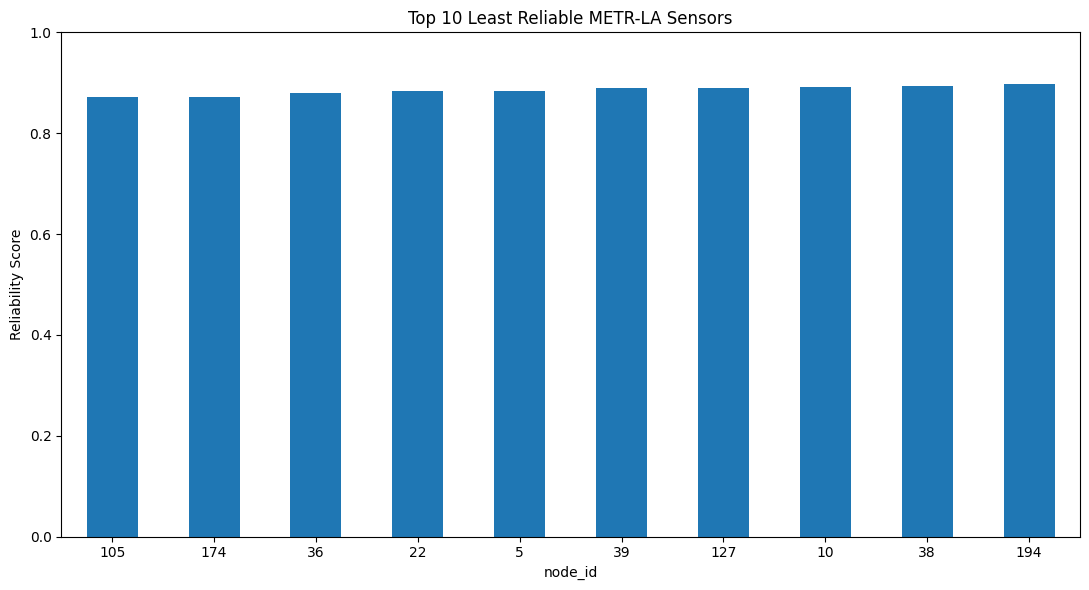

In [21]:
plot_df = (
    least_reliable
    .sort_values(
        "reliability_score",
        ascending=True
    )
    .set_index("node_id")
)


ax = plot_df[
    "reliability_score"
].plot.bar(
    figsize=(11, 6)
)

ax.set_title(
    "Top 10 Least Reliable METR-LA Sensors"
)

ax.set_xlabel("node_id")
ax.set_ylabel("Reliability Score")

ax.set_ylim(
    0,
    1
)

plt.xticks(
    rotation=0
)

plt.tight_layout()
plt.show()

In [22]:
component_summary = (
    summary[
        [
            "zero_rate",
            "cusum_rate",
            "ewma_rate",
            "reliability_score"
        ]
    ]
    .describe()
)


print("=" * 65)
print("RELIABILITY COMPONENT DISTRIBUTION")
print("=" * 65)

print(
    component_summary
    .round(4)
    .to_string()
)

RELIABILITY COMPONENT DISTRIBUTION
       zero_rate  cusum_rate  ewma_rate  reliability_score
count   207.0000    207.0000   207.0000           207.0000
mean      0.0713      0.0319     0.1063             0.9298
std       0.0257      0.0130     0.0504             0.0184
min       0.0542      0.0088     0.0247             0.8715
25%       0.0550      0.0222     0.0649             0.9174
50%       0.0578      0.0322     0.0994             0.9318
75%       0.0800      0.0413     0.1503             0.9426
max       0.2296      0.0712     0.2854             0.9639


In [23]:
# ------------------------------------------------------------
# OVERALL RELIABILITY COMPONENT CONTRIBUTIONS
# ------------------------------------------------------------

summary["zero_contribution"] = (
    ZERO_WEIGHT
    * summary["zero_rate"]
)

summary["cusum_contribution"] = (
    CUSUM_WEIGHT
    * summary["cusum_rate"]
)

summary["ewma_contribution"] = (
    EWMA_WEIGHT
    * summary["ewma_rate"]
)


contribution_cols = [
    "zero_contribution",
    "cusum_contribution",
    "ewma_contribution"
]


mean_contributions = (
    summary[contribution_cols]
    .mean()
)


print("=" * 70)
print("MEAN RELIABILITY PENALTY CONTRIBUTIONS")
print("=" * 70)

print(
    mean_contributions
    .round(6)
    .to_string()
)


largest_component = (
    mean_contributions.idxmax()
    .replace("_contribution", "")
)


print(
    "\nLargest average penalty component:",
    largest_component
)


print("\nDominant component across sensors:")

dominant_counts = (
    summary[contribution_cols]
    .idxmax(axis=1)
    .str.replace(
        "_contribution",
        "",
        regex=False
    )
    .value_counts()
)

print(
    dominant_counts.to_string()
)


# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

assert (
    summary[contribution_cols] >= 0
).all().all()

assert np.isclose(
    summary[contribution_cols].sum(axis=1),
    summary["reliability_penalty"]
).all()

assert dominant_counts.sum() == 207


print(
    "\nPASS: Reliability penalty contributions validated."
)

MEAN RELIABILITY PENALTY CONTRIBUTIONS
zero_contribution     0.035642
cusum_contribution    0.007978
ewma_contribution     0.026586

Largest average penalty component: zero

Dominant component across sensors:
zero    147
ewma     60

PASS: Reliability penalty contributions validated.


In [24]:
tests = {
    "207 sensors loaded":
        traffic["node_id"].nunique() == 207,

    "Unique sensor-timestamp observations":
        not traffic.duplicated(
            ["node_id", "t0_timestamp"]
        ).any(),

    "Near-zero failure metric computed":
        failure_df["zero_rate"]
        .between(0, 1)
        .all(),

    "Seasonal weekday keys valid":
        traffic["day_of_week"]
        .between(0, 6)
        .all(),

    "Seasonal time slots valid":
        traffic["time_slot"]
        .between(0, 287)
        .all(),

    "Seasonal baseline available":
        baseline_match_rate > 0.99,

    "Residual series available":
        len(drift_data) > 0,

    "Hourly seasonality reduced":
        residual_hourly_range
        < raw_hourly_range,

    "CUSUM completed":
        len(drift_df) == 207,

    "EWMA completed":
        len(drift_df) == 207,

    "CUSUM rates valid":
        drift_df["cusum_rate"]
        .between(0, 1)
        .all(),

    "EWMA rates valid":
        drift_df["ewma_rate"]
        .between(0, 1)
        .all(),

    "Reliability scores valid":
        summary["reliability_score"]
        .between(0, 1)
        .all(),

    "Top 10 identified":
        len(least_reliable) == 10
}


print("=" * 70)
print("DE-SEASONALIZED SENSOR RELIABILITY VALIDATION")
print("=" * 70)


for name, passed in tests.items():

    print(
        f"{'PASS' if passed else 'FAIL':4} : {name}"
    )


print("=" * 70)


failed_tests = [
    name
    for name, passed in tests.items()
    if not passed
]


if len(failed_tests) == 0:

    print("\nALL TEST CASES PASSED")

else:

    print(
        f"\n{len(failed_tests)} TEST(S) FAILED"
    )

    for name in failed_tests:

        print(
            " -",
            name
        )

    raise AssertionError(
        f"Validation failed: {failed_tests}"
    )

DE-SEASONALIZED SENSOR RELIABILITY VALIDATION
PASS : 207 sensors loaded
PASS : Unique sensor-timestamp observations
PASS : Near-zero failure metric computed
PASS : Seasonal weekday keys valid
PASS : Seasonal time slots valid
PASS : Seasonal baseline available
PASS : Residual series available
PASS : Hourly seasonality reduced
PASS : CUSUM completed
PASS : EWMA completed
PASS : CUSUM rates valid
PASS : EWMA rates valid
PASS : Reliability scores valid
PASS : Top 10 identified

ALL TEST CASES PASSED


In [25]:
print("=" * 70)
print("SENSOR RELIABILITY ANALYSIS SUMMARY")
print("=" * 70)

print(
    f"""
Sensors analyzed          : {len(summary)}
Near-zero threshold       : <= {ZERO_THRESHOLD:.1f} mph
Overall near-zero rate    : {overall_zero_rate:.4%}

Seasonal baseline         : sensor × weekday × 5-minute slot
Drift input               : de-seasonalized speed residuals
Near-zero values in drift : excluded

Total CUSUM flags         : {summary["cusum_flags"].sum():,}
Total EWMA flags          : {summary["ewma_flags"].sum():,}

Mean CUSUM rate           : {summary["cusum_rate"].mean():.4%}
Mean EWMA rate            : {summary["ewma_rate"].mean():.4%}

Mean reliability          : {summary["reliability_score"].mean():.4f}
Lowest reliability        : {summary["reliability_score"].min():.4f}
Highest reliability       : {summary["reliability_score"].max():.4f}

Least reliable node       : {int(least_reliable.iloc[0]["node_id"])}
"""
)

print(
    "Zero/stuck-at-zero faults are measured directly "
    "from raw sensor readings."
)

print(
    "CUSUM and EWMA are applied to de-seasonalized "
    "residuals rather than raw traffic speed."
)

print(
    "\nReliability weights are heuristic and the score "
    "should be interpreted as a composite diagnostic "
    "index, not a calibrated probability of sensor failure."
)

print(
    "\nSensor reliability analysis completed successfully."
)

SENSOR RELIABILITY ANALYSIS SUMMARY

Sensors analyzed          : 207
Near-zero threshold       : <= 1.0 mph
Overall near-zero rate    : 7.1285%

Seasonal baseline         : sensor × weekday × 5-minute slot
Drift input               : de-seasonalized speed residuals
Near-zero values in drift : excluded

Total CUSUM flags         : 93,752
Total EWMA flags          : 312,454

Mean CUSUM rate           : 3.1912%
Mean EWMA rate            : 10.6346%

Mean reliability          : 0.9298
Lowest reliability        : 0.8715
Highest reliability       : 0.9639

Least reliable node       : 105

Zero/stuck-at-zero faults are measured directly from raw sensor readings.
CUSUM and EWMA are applied to de-seasonalized residuals rather than raw traffic speed.

Reliability weights are heuristic and the score should be interpreted as a composite diagnostic index, not a calibrated probability of sensor failure.

Sensor reliability analysis completed successfully.


In [26]:
# ============================================================
# FINAL SENSOR RELIABILITY VALIDATION
# ============================================================

print("=" * 70)
print("FINAL SENSOR RELIABILITY VALIDATION")
print("=" * 70)

# 1. Sensor coverage
assert len(summary) == 207
assert summary["node_id"].nunique() == 207
print("PASS: All 207 sensors are represented.")

# 2. Reliability score validity
assert summary["reliability_score"].notna().all()
assert np.isfinite(summary["reliability_score"]).all()
assert summary["reliability_score"].between(0, 1).all()
print("PASS: Reliability scores are finite and bounded [0, 1].")

# 3. Component-rate validity
for col in ["zero_rate", "cusum_rate", "ewma_rate"]:
    assert summary[col].notna().all()
    assert np.isfinite(summary[col]).all()
    assert summary[col].between(0, 1).all()

print("PASS: Zero, CUSUM, and EWMA rates are valid.")

# 4. Reliability formula consistency
expected_penalty = (
    ZERO_WEIGHT * summary["zero_rate"]
    + CUSUM_WEIGHT * summary["cusum_rate"]
    + EWMA_WEIGHT * summary["ewma_rate"]
)

assert np.allclose(
    summary["reliability_penalty"],
    expected_penalty
)

assert np.allclose(
    summary["reliability_score"],
    1.0 - expected_penalty
)

print("PASS: Reliability formula is internally consistent.")

# 5. Heuristic weights
assert np.isclose(
    ZERO_WEIGHT + CUSUM_WEIGHT + EWMA_WEIGHT,
    1.0
)
print("PASS: Reliability weights sum to 1.")

# 6. Reference and monitoring periods must not overlap
assert (
    reference_data["t0_timestamp"].max()
    < monitoring_data["t0_timestamp"].min()
)
print("PASS: Reference and monitoring periods do not overlap.")

# 7. Fixed reference parameters
assert len(reference_control) == 207
assert reference_control["node_id"].nunique() == 207
assert (reference_control["reference_std"] > 0).all()
assert np.isfinite(reference_control["reference_std"]).all()

print("PASS: Fixed reference parameters are valid for all sensors.")

# 8. Out-of-sample baseline coverage
assert baseline_match_rate > 0.99
print(
    f"PASS: Monitoring baseline coverage = "
    f"{baseline_match_rate:.4%}."
)

# 9. Drift results
assert len(drift_df) == 207
assert drift_df["node_id"].nunique() == 207
assert (drift_df["drift_observations"] > 0).all()

assert drift_df["cusum_rate"].between(0, 1).all()
assert drift_df["ewma_rate"].between(0, 1).all()

print("PASS: Out-of-sample drift analysis covers all sensors.")
print("PASS: Out-of-sample drift analysis covers all sensors.")
# 10. Top-10 ranking
assert len(least_reliable) == 10
assert least_reliable["node_id"].nunique() == 10
assert least_reliable["reliability_score"].is_monotonic_increasing

print("PASS: Top-10 least reliable sensor ranking is valid.")

print("=" * 70)
print("ALL TEST CASES PASSED")
print("=" * 70)

FINAL SENSOR RELIABILITY VALIDATION
PASS: All 207 sensors are represented.
PASS: Reliability scores are finite and bounded [0, 1].
PASS: Zero, CUSUM, and EWMA rates are valid.
PASS: Reliability formula is internally consistent.
PASS: Reliability weights sum to 1.
PASS: Reference and monitoring periods do not overlap.
PASS: Fixed reference parameters are valid for all sensors.
PASS: Monitoring baseline coverage = 99.9667%.
PASS: Out-of-sample drift analysis covers all sensors.
PASS: Out-of-sample drift analysis covers all sensors.
PASS: Top-10 least reliable sensor ranking is valid.
ALL TEST CASES PASSED
